
=== HANSEN THRESHOLD REGRESSION (GDP GROWTH): GLOBAL PANEL (ALL COUNTRIES) ===
Searching 1000 thresholds between 22.9% and 97.0% Debt-to-GDP...


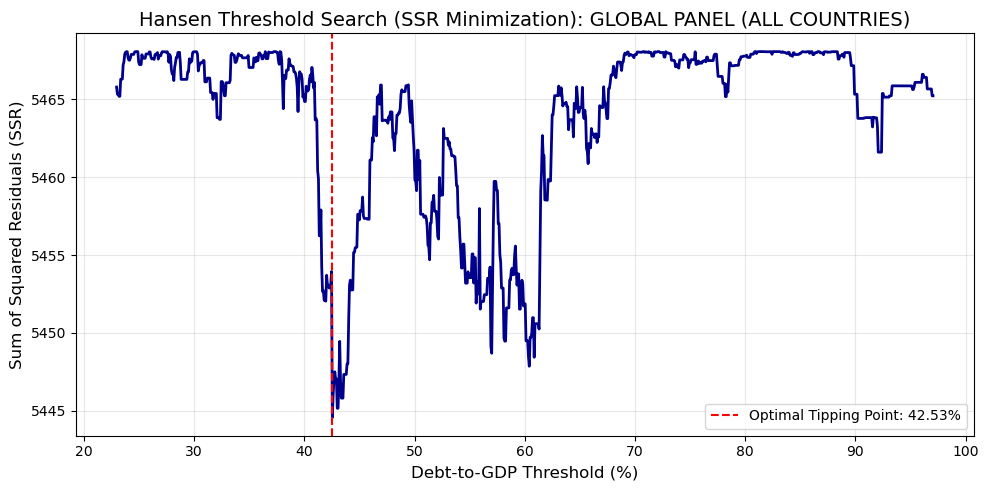


>> OPTIMAL REINHART-ROGOFF THRESHOLD FOUND AT: 42.53% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                 -2.4583     1.1473    -2.1426     0.0324     -4.7096     -0.2071
Debt_Below_Gamma                      -0.0149     0.0098    -1.5141     0.1303     -0.0341      0.0044
Debt_Above_Gamma                      -0.0012     0.0063    -0.1931     0.8469     -0.0135      0.0111
Gross capital formation (% of GDP)     0.2395     0.0378     6.3317     0.0000      0.1653      0.3137
Inflation (Annual %)                  -0.0430     0.0294    -1.4620     0.1440     -0.1007      0.0147
Population growth (annual %)           0.1168     0.1745     0.6696     0.5033     -0.2256      0.4593

>

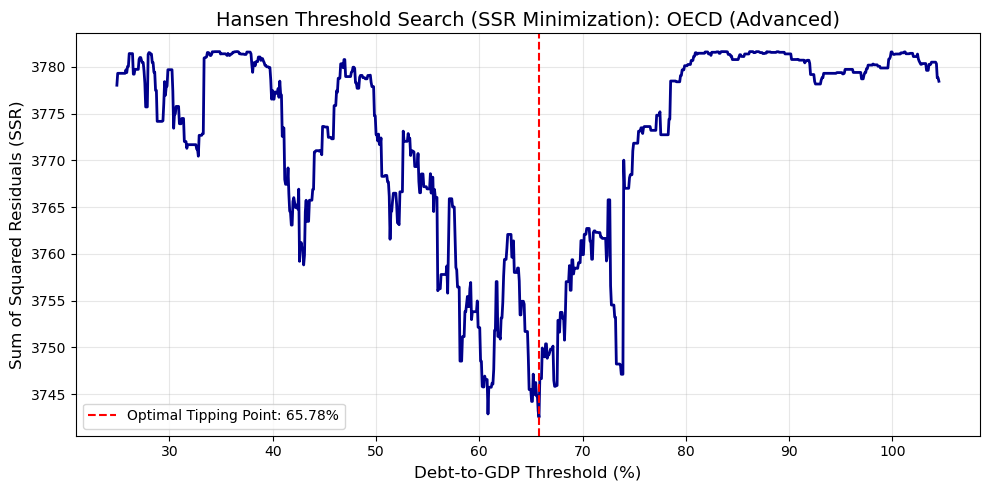


>> OPTIMAL REINHART-ROGOFF THRESHOLD FOUND AT: 65.78% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                 -2.2038     1.4056    -1.5678     0.1173     -4.9629      0.5554
Debt_Below_Gamma                      -0.0152     0.0089    -1.7036     0.0889     -0.0328      0.0023
Debt_Above_Gamma                      -0.0019     0.0060    -0.3198     0.7492     -0.0137      0.0099
Gross capital formation (% of GDP)     0.2351     0.0471     4.9867     0.0000      0.1425      0.3276
Inflation (Annual %)                  -0.1271     0.0364    -3.4932     0.0005     -0.1985     -0.0557
Population growth (annual %)          -0.0521     0.2696    -0.1933     0.8468     -0.5813      0.4771

>

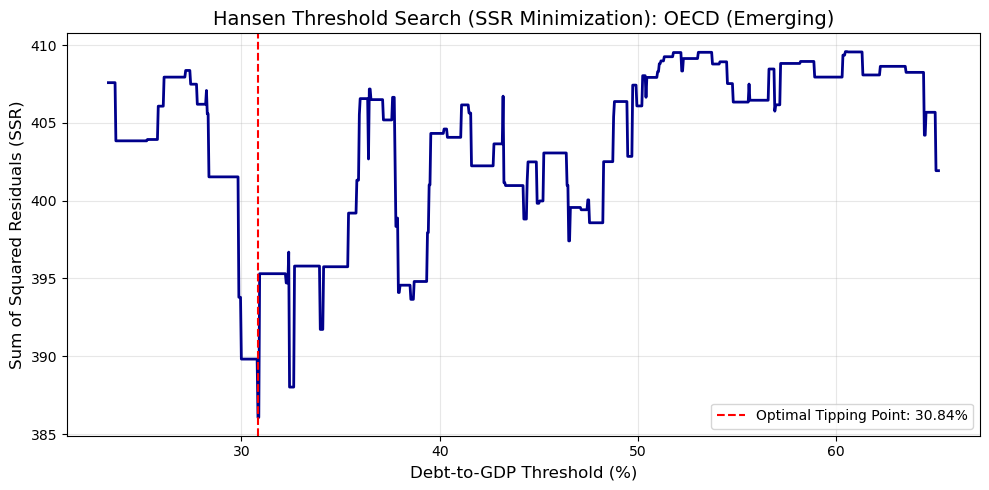


>> OPTIMAL REINHART-ROGOFF THRESHOLD FOUND AT: 30.84% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                 -3.7739     2.8654    -1.3171     0.1906     -9.4525      1.9047
Debt_Below_Gamma                      -0.0923     0.0446    -2.0712     0.0407     -0.1806     -0.0040
Debt_Above_Gamma                      -0.0230     0.0286    -0.8051     0.4225     -0.0797      0.0337
Gross capital formation (% of GDP)     0.3889     0.0808     4.8129     0.0000      0.2288      0.5491
Inflation (Annual %)                  -0.0463     0.0357    -1.2997     0.1964     -0.1170      0.0243
Population growth (annual %)          -0.0056     0.8256    -0.0068     0.9946     -1.6418      1.6306

>

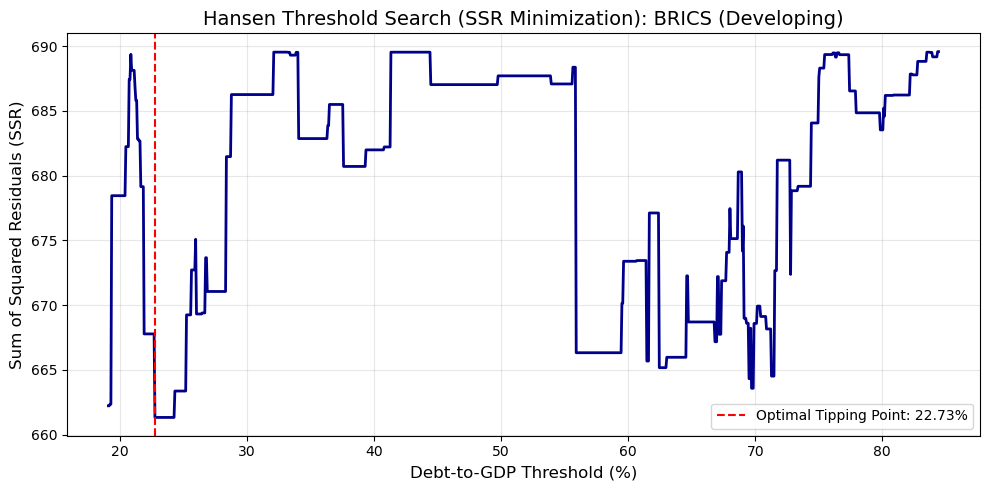


>> OPTIMAL REINHART-ROGOFF THRESHOLD FOUND AT: 22.73% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                  5.8218     3.1257     1.8626     0.0652     -0.3738      12.017
Debt_Below_Gamma                      -0.1857     0.0628    -2.9547     0.0038     -0.3102     -0.0611
Debt_Above_Gamma                      -0.0821     0.0168    -4.8752     0.0000     -0.1154     -0.0487
Gross capital formation (% of GDP)     0.1153     0.0953     1.2104     0.2288     -0.0735      0.3041
Inflation (Annual %)                   0.0968     0.0216     4.4764     0.0000      0.0540      0.1397
Population growth (annual %)           0.1372     0.3836     0.3577     0.7213     -0.6231      0.8976

>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from linearmodels.panel import PanelOLS
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. LOAD MASTER DATA
# ==============================================================================
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
master_file = PROCESSED_DIR / "master_panel_data.csv"

df = pd.read_csv(master_file)
df = df.set_index(['Country Name', 'Year'])

BRICS_NATIONS = ["Brazil", "Russia", "India", "China", "Egypt", "United Arab Emirates"]
OECD_EMERGING = ["Chile", "Colombia", "Costa Rica", "Turkey", "Hungary", "Poland"]

def categorize_economy(country):
    if country in BRICS_NATIONS: return 'BRICS (Developing)'
    elif country in OECD_EMERGING: return 'OECD (Emerging)'
    else: return 'OECD (Advanced)'

df['Economic_Bloc'] = [categorize_economy(c) for c, y in df.index]

Y_VAR = 'GDP growth (annual %)'
DEBT_VAR = 'General Government Debt (% of GDP)'
EXOG_VARS = [
    'Gross capital formation (% of GDP)',
    'Inflation (Annual %)',
    'Population growth (annual %)'
]

# ==============================================================================
# 2. HANSEN'S PANEL THRESHOLD GRID SEARCH ALGORITHM
# ==============================================================================
def run_threshold_regression(data, bloc_name):
    print(f"\n{'='*85}")
    print(f"=== HANSEN THRESHOLD REGRESSION (GDP GROWTH): {bloc_name.upper()} ===")
    print(f"{'='*85}")
    
    reg_data = data[[Y_VAR, DEBT_VAR] + EXOG_VARS].dropna()
    
    if len(reg_data) < 30:
        print("Skipping due to insufficient data.")
        return
        
    min_debt = reg_data[DEBT_VAR].quantile(0.15)
    max_debt = reg_data[DEBT_VAR].quantile(0.85)
    
    grid = np.linspace(min_debt, max_debt, 1000)
    
    best_ssr = np.inf
    best_gamma = None
    best_res = None
    ssr_history = []
    
    print(f"Searching 1000 thresholds between {min_debt:.1f}% and {max_debt:.1f}% Debt-to-GDP...")
    
    for gamma in grid:
        reg_data['Debt_Below_Gamma'] = reg_data[DEBT_VAR] * (reg_data[DEBT_VAR] <= gamma)
        reg_data['Debt_Above_Gamma'] = reg_data[DEBT_VAR] * (reg_data[DEBT_VAR] > gamma)
        
        Y = reg_data[Y_VAR]
        X = sm.add_constant(reg_data[['Debt_Below_Gamma', 'Debt_Above_Gamma'] + EXOG_VARS])
        
        model = PanelOLS(Y, X, entity_effects=True, time_effects=True)
        res = model.fit(cov_type='robust')
        
        ssr = float(res.resids.squeeze().dot(res.resids.squeeze()))
        ssr_history.append((gamma, ssr))
        
        if ssr < best_ssr:
            best_ssr = ssr
            best_gamma = gamma
            best_res = res

    # --- 3. VISUALIZATION OF THE THRESHOLD SEARCH ---
    gammas, ssrs = zip(*ssr_history)
    
    plt.figure(figsize=(10, 5))
    plt.plot(gammas, ssrs, color='darkblue', linewidth=2)
    plt.axvline(x=best_gamma, color='red', linestyle='--', label=f'Optimal Tipping Point: {best_gamma:.2f}%')
    plt.title(f'Hansen Threshold Search (SSR Minimization): {bloc_name}', fontsize=14)
    plt.xlabel('Debt-to-GDP Threshold (%)', fontsize=12)
    plt.ylabel('Sum of Squared Residuals (SSR)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 4. PRINT BEST MODEL RESULTS ---
    print(f"\n>> OPTIMAL REINHART-ROGOFF THRESHOLD FOUND AT: {best_gamma:.2f}% DEBT-TO-GDP <<\n")
    print(best_res.summary.tables[1])

    # ---------------------------------------------------------
    # TEST 1: One-Way ANOVA on the Dependent Variable
    # ---------------------------------------------------------
    mask_low = reg_data[DEBT_VAR] <= best_gamma
    mask_high = reg_data[DEBT_VAR] > best_gamma

    y_low = reg_data[mask_low][Y_VAR].dropna()
    y_high = reg_data[mask_high][Y_VAR].dropna()

    f_stat_anova, p_val_anova = stats.f_oneway(y_low, y_high)

    print("\n>> 1. ONE-WAY ANOVA (Difference in Means across Regimes):")
    print(f"   - Low Debt Regime Mean ({Y_VAR}):  {y_low.mean():.4f}")
    print(f"   - High Debt Regime Mean ({Y_VAR}): {y_high.mean():.4f}")
    print(f"   - F-Statistic: {f_stat_anova:.4f}")
    print(f"   - P-Value:     {p_val_anova:.4e}")
    if p_val_anova < 0.05:
        print("   -> Conclusion: SIGNIFICANT difference in macroeconomic outcomes between regimes.")
    else:
        print("   -> Conclusion: NO significant difference in outcomes between regimes.")

    # ---------------------------------------------------------
    # TEST 2: Wald F-Test on Regression Coefficients 
    # ---------------------------------------------------------
    print("\n>> 2. WALD F-TEST (Structural Break in Debt Coefficients):")
    print("   - Null Hypothesis (H0): Debt_Below_Gamma coefficient == Debt_Above_Gamma coefficient")

    try:
        # Robust restriction formulation for linearmodels
        idx = best_res.params.index
        R = pd.DataFrame(np.zeros((1, len(idx))), columns=idx)
        R.loc[0, 'Debt_Below_Gamma'] = 1
        R.loc[0, 'Debt_Above_Gamma'] = -1
        
        wald = best_res.wald_test(restriction=R)
        print(f"   - F-Statistic: {wald.stat:.4f}")
        print(f"   - P-Value:     {wald.pval:.4e}")
        if wald.pval < 0.05:
            print("   -> Conclusion: SIGNIFICANT structural break. Debt efficiency fundamentally shifts across the threshold.")
        else:
            print("   -> Conclusion: NO significant structural break.")
    except Exception as e:
        print(f"   -> Could not perform Wald test. Error: {e}")

    print("="*85 + "\n")

# ==============================================================================
# 3. EXECUTE FOR GLOBAL PANEL & CORE BLOCS
# ==============================================================================
if __name__ == "__main__":
    
    # 1. RUN GLOBAL BASELINE (All Countries Combined)
    run_threshold_regression(df, "GLOBAL PANEL (ALL COUNTRIES)")
    
    # 2. RUN INDIVIDUAL BLOCS
    for bloc in ['OECD (Advanced)', 'OECD (Emerging)', 'BRICS (Developing)']:
        df_bloc = df[df['Economic_Bloc'] == bloc]
        run_threshold_regression(df_bloc, bloc)